## Julieta Madrigal Flores

## Rodolfo Del Castillo Wilches

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

## FUNCIONES DE LA CLASE 19 (Payoff Diagrams)

In [2]:
# payoff_estrategia(): Calcula el P&L para un array de precios
# graficar_estrategia(): Genera el gráfico con áreas de ganancia/pérdida

def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    """
    Grafica el P&L de una estrategia con formato estándar.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    pnl     : array de P&L calculado
    titulo  : título del gráfico
    S0      : precio actual (línea vertical opcional)
    K_lines : lista de tuplas (strike, etiqueta) para líneas verticales
    """
    plt.figure(figsize=(10, 6))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2, label='P&L Estrategia')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    if S0 is not None:
        plt.axvline(S0, color='green', linewidth=1.5, linestyle='--',
                   alpha=0.7, label=f'S0 = ${S0:.2f}')

    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', alpha=0.6, label=label)

    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red', label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## OBTENCIÓN DE DATOS REALES DE SPY

In [3]:
# Se descarga el precio actual de SPY y la cadena de opciones
# con vencimiento al 17 de abril de 2026
# Se usa el precio mid (promedio bid/ask) como prima real de mercado

ticker = "SPY"
expiry_date = "2026-04-17"

# Descargar precio actual
spy = yf.Ticker(ticker)
S0 = spy.history(period="1d")['Close'].iloc[-1]
print(f"\n Precio actual de SPY: ${S0:.2f}")
print(f" Fecha de vencimiento: {expiry_date}")

# Obtener cadena de opciones
try:
    options = spy.option_chain(expiry_date)
    calls = options.calls
    puts = options.puts

    # Calcular precio mid (bid + ask) / 2
    calls['mid'] = (calls['bid'] + calls['ask']) / 2
    puts['mid'] = (puts['bid'] + puts['ask']) / 2

    print(f"   Calls disponibles: {len(calls)}")
    print(f"   Puts disponibles: {len(puts)}")

except Exception as e:
    print(f"Error: {e}")
    print("Buscando fechas de vencimiento disponibles...")
    available = spy.options
    print(f"Fechas disponibles: {available[:5]}")
    # Fallback: usar la primera fecha disponible
    expiry_date = available[0]
    print(f"Usando fecha alternativa: {expiry_date}")
    options = spy.option_chain(expiry_date)
    calls = options.calls
    puts = options.puts
    calls['mid'] = (calls['bid'] + calls['ask']) / 2
    puts['mid'] = (puts['bid'] + puts['ask']) / 2

# Encontrar strike ATM (At-The-Money)
atm_strike = calls.iloc[(calls['strike'] - S0).abs().argsort()[:1]]['strike'].values[0]
print(f" Strike ATM: ${atm_strike}")

# Definir rango de precios para los gráficos (85% al 115% del spot)
S_range = np.linspace(S0 * 0.85, S0 * 1.15, 500)


 Precio actual de SPY: $697.34
 Fecha de vencimiento: 2026-04-17
   Calls disponibles: 250
   Puts disponibles: 225
 Strike ATM: $697.0


## ESTRATEGIA 1 - BUTTERFLY SPREAD


Strikes seleccionados: K1=$696.0, K2=$697.0, K3=$698.0
Primas: C1=$3.85, C2=$3.20, C3=$2.68

 Métricas Butterfly:
   Prima neta pagada: $0.14
   Ganancia máxima: $0.86 (si ST = $697.0)
   Pérdida máxima: $-0.14
   Break-evens: $696.14 y $697.86


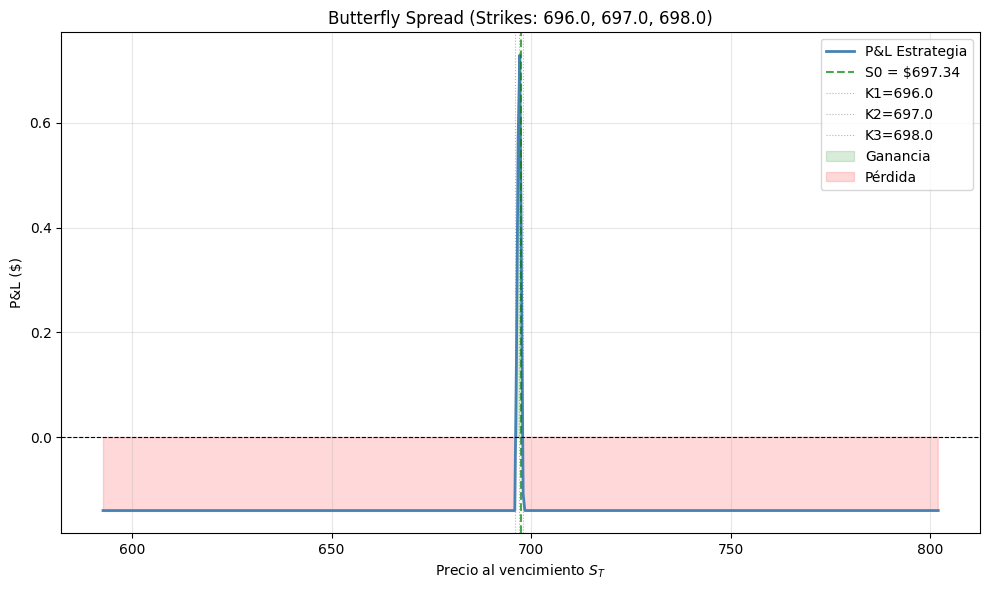

In [4]:
# Compra de call K1, venta de 2 calls K2, compra de call K3
# Mercado con alta precisión - SPY debe cerrar en K2
# Vega negativa, Theta positiva


# Seleccionar strikes cercanos al ATM
calls_near = calls[calls['strike'].between(S0 * 0.95, S0 * 1.05)]

if len(calls_near) >= 3:
    strikes_bf = sorted(calls_near['strike'].values)
    idx_atm = list(strikes_bf).index(atm_strike) if atm_strike in strikes_bf else len(strikes_bf)//2

    if idx_atm > 0 and idx_atm < len(strikes_bf) - 1:
        K1_bf = strikes_bf[idx_atm - 1]  # Strike inferior (long)
        K2_bf = atm_strike                # Strike central (short 2x)
        K3_bf = strikes_bf[idx_atm + 1]  # Strike superior (long)
    else:
        K1_bf = strikes_bf[0]
        K2_bf = atm_strike
        K3_bf = strikes_bf[-1]

    # Obtener primas reales
    C1_bf = calls[calls['strike'] == K1_bf]['mid'].values[0]
    C2_bf = calls[calls['strike'] == K2_bf]['mid'].values[0]
    C3_bf = calls[calls['strike'] == K3_bf]['mid'].values[0]

    # Construir la estrategia según la clase 22
    legs_butterfly = [
        {'tipo': 'call', 'K': K1_bf, 'prima': C1_bf, 'posicion': +1},  # Long call inferior
        {'tipo': 'call', 'K': K2_bf, 'prima': C2_bf, 'posicion': -2},  # Short 2 calls central
        {'tipo': 'call', 'K': K3_bf, 'prima': C3_bf, 'posicion': +1},  # Long call superior
    ]

    # Calcular P&L y métricas
    pnl_butterfly = payoff_estrategia(S_range, legs_butterfly)

    prima_neta_bf = C1_bf - 2*C2_bf + C3_bf
    ganancia_max_bf = (K2_bf - K1_bf) - prima_neta_bf
    perdida_max_bf = -prima_neta_bf
    be_inf_bf = K1_bf + prima_neta_bf
    be_sup_bf = K3_bf - prima_neta_bf

    print(f"\nStrikes seleccionados: K1=${K1_bf}, K2=${K2_bf}, K3=${K3_bf}")
    print(f"Primas: C1=${C1_bf:.2f}, C2=${C2_bf:.2f}, C3=${C3_bf:.2f}")
    print(f"\n Métricas Butterfly:")
    print(f"   Prima neta pagada: ${prima_neta_bf:.2f}")
    print(f"   Ganancia máxima: ${ganancia_max_bf:.2f} (si ST = ${K2_bf})")
    print(f"   Pérdida máxima: ${perdida_max_bf:.2f}")
    print(f"   Break-evens: ${be_inf_bf:.2f} y ${be_sup_bf:.2f}")

    # Generar gráfico
    graficar_estrategia(S_range, pnl_butterfly,
                       f'Butterfly Spread (Strikes: {K1_bf}, {K2_bf}, {K3_bf})',
                       S0=S0,
                       K_lines=[(K1_bf,f'K1={K1_bf}'),(K2_bf,f'K2={K2_bf}'),(K3_bf,f'K3={K3_bf}')])
else:
    print("⚠️ No hay suficientes strikes para construir el butterfly")


## ESTRATEGIA 2 - IRON CONDOR


Strikes seleccionados:
   Put spread: long $690.0, short $691.0
   Call spread: short $703.0, long $704.0
Primas: P_l=$1.15, P_s=$1.29, C_s=$0.83, C_l=$0.64

 Métricas Iron Condor:
   Prima cobrada: $0.34 (ganancia máxima)
   Pérdida máxima: $0.66
   Zona de ganancia: [691.0, 703.0]
   Break-evens: $690.66 y $703.34


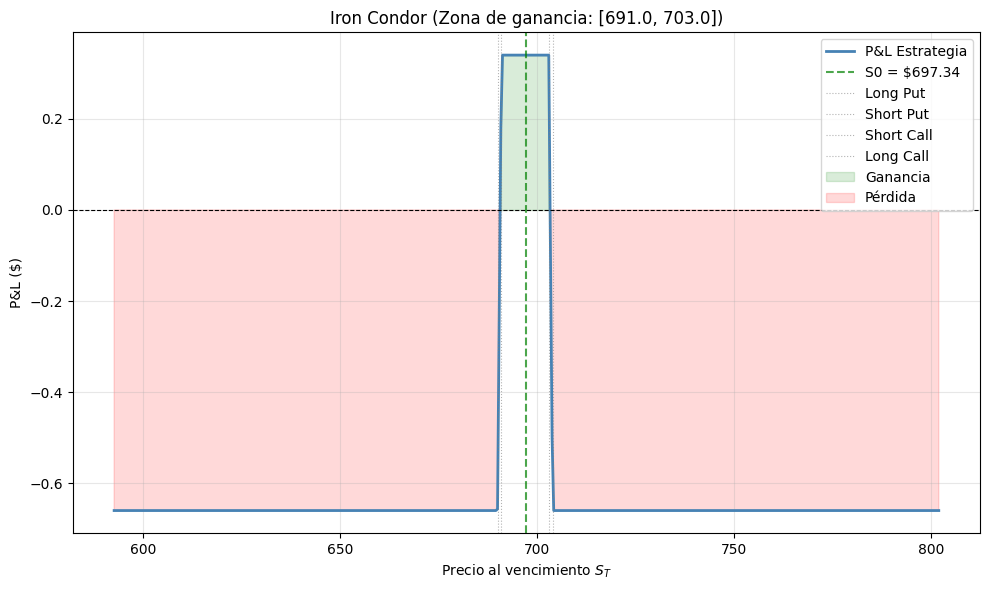

In [5]:
# Venta de put spread + venta de call spread
# Mercado Neutral - SPY debe quedar dentro del rango
# Prima cobrada, zona de ganancia ancha


# Seleccionar strikes OTM para ambos lados
puts_otm = puts[puts['strike'] < atm_strike - 5]
calls_otm = calls[calls['strike'] > atm_strike + 5]

if len(puts_otm) >= 2 and len(calls_otm) >= 2:
    # Configurar put spread (lado de caída)
    put_strikes = sorted(puts_otm['strike'].values)
    K_pl = put_strikes[-2]  # Long put (más OTM)
    K_ps = put_strikes[-1]  # Short put (menos OTM)

    # Configurar call spread (lado de subida)
    call_strikes = sorted(calls_otm['strike'].values)
    K_cs = call_strikes[0]   # Short call (menos OTM)
    K_cl = call_strikes[1]   # Long call (más OTM)

    # Obtener primas reales
    P_l = puts[puts['strike'] == K_pl]['mid'].values[0]
    P_s = puts[puts['strike'] == K_ps]['mid'].values[0]
    C_s = calls[calls['strike'] == K_cs]['mid'].values[0]
    C_l = calls[calls['strike'] == K_cl]['mid'].values[0]

    # Construir la estrategia según la clase 22
    legs_condor = [
        {'tipo': 'put', 'K': K_pl, 'prima': P_l, 'posicion': +1},  # Long put (protección)
        {'tipo': 'put', 'K': K_ps, 'prima': P_s, 'posicion': -1},  # Short put (venta)
        {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1}, # Short call (venta)
        {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1},  # Long call (protección)
    ]

    # Calcular P&L y métricas
    pnl_condor = payoff_estrategia(S_range, legs_condor)

    prima_cobrada_ic = (P_s - P_l) + (C_s - C_l)
    perdida_max_ic = (K_ps - K_pl) - prima_cobrada_ic
    zona_ganancia = f"[{K_ps}, {K_cs}]"
    be_low_ic = K_ps - prima_cobrada_ic
    be_high_ic = K_cs + prima_cobrada_ic

    print(f"\nStrikes seleccionados:")
    print(f"   Put spread: long ${K_pl}, short ${K_ps}")
    print(f"   Call spread: short ${K_cs}, long ${K_cl}")
    print(f"Primas: P_l=${P_l:.2f}, P_s=${P_s:.2f}, C_s=${C_s:.2f}, C_l=${C_l:.2f}")
    print(f"\n Métricas Iron Condor:")
    print(f"   Prima cobrada: ${prima_cobrada_ic:.2f} (ganancia máxima)")
    print(f"   Pérdida máxima: ${perdida_max_ic:.2f}")
    print(f"   Zona de ganancia: {zona_ganancia}")
    print(f"   Break-evens: ${be_low_ic:.2f} y ${be_high_ic:.2f}")

    # Generar gráfico
    graficar_estrategia(S_range, pnl_condor,
                       f'Iron Condor (Zona de ganancia: {zona_ganancia})',
                       S0=S0,
                       K_lines=[(K_pl,'Long Put'),(K_ps,'Short Put'),
                                (K_cs,'Short Call'),(K_cl,'Long Call')])
else:
    print("⚠️ No hay suficientes strikes OTM para construir el Iron Condor")

## ESTRATEGIA 3 - COVERED CALL


Strike call vendido: $698.0
Prima cobrada: $2.68

 Métricas Covered Call:
   Prima cobrada: $2.68
   Ganancia máxima: $3.34 (si ST ≥ $698.0)
   Pérdida máxima: Teóricamente ilimitada a la baja
   Break-even: $694.66


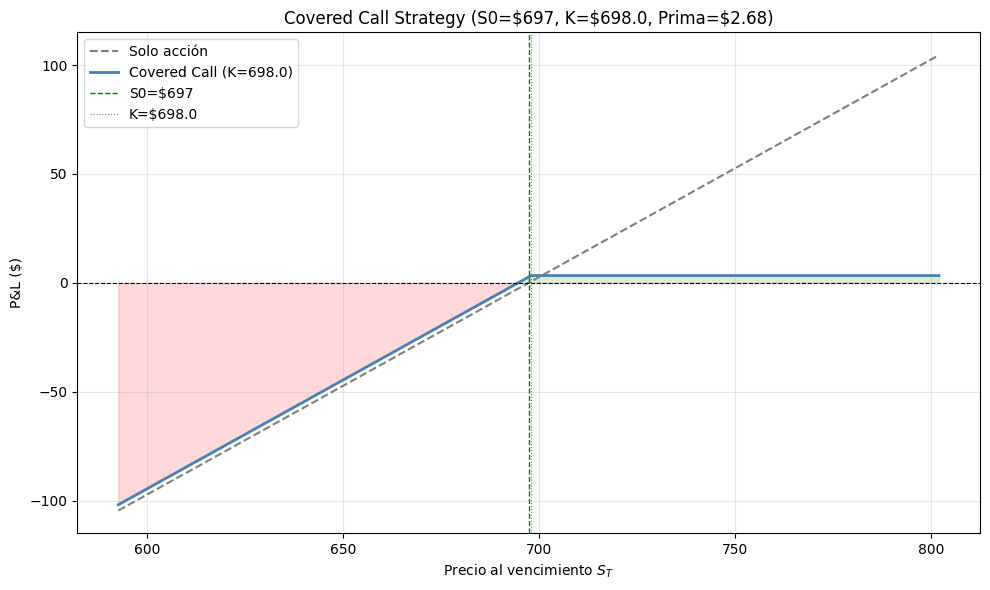

In [6]:
# Compra de acciones + venta de call OTM
# Mercado neutral a ligeramente alcista
# Genera ingreso, limita el upside

# Seleccionar call OTM (2-3% arriba del spot)
call_otm_cc = calls[calls['strike'] > S0]
if len(call_otm_cc) > 0:
    K_cc = call_otm_cc.iloc[0]['strike']
    C_cc = call_otm_cc.iloc[0]['mid']
else:
    K_cc = atm_strike + 15
    C_cc = 5.0

# Calcular P&L: Long stock + Short call
pnl_accion = S_range - S0
pnl_covered = pnl_accion + (-np.maximum(S_range - K_cc, 0) + C_cc)

ganancia_max_cc = K_cc - S0 + C_cc
be_cc = S0 - C_cc

print(f"\nStrike call vendido: ${K_cc}")
print(f"Prima cobrada: ${C_cc:.2f}")
print(f"\n Métricas Covered Call:")
print(f"   Prima cobrada: ${C_cc:.2f}")
print(f"   Ganancia máxima: ${ganancia_max_cc:.2f} (si ST ≥ ${K_cc})")
print(f"   Pérdida máxima: Teóricamente ilimitada a la baja")
print(f"   Break-even: ${be_cc:.2f}")

# comparando con solo acciones
plt.figure(figsize=(10, 6))
plt.plot(S_range, pnl_accion, color='gray', linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_covered, color='steelblue', linewidth=2,
         label=f'Covered Call (K={K_cc})')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0, color='green', linewidth=1.0, linestyle='--', label=f'S0=${S0:.0f}')
plt.axvline(K_cc, color='gray', linewidth=0.8, linestyle=':', label=f'K=${K_cc}')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered>0), alpha=0.15, color='green')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered<0), alpha=0.15, color='red')
plt.xlabel('Precio al vencimiento $S_T$')
plt.ylabel('P&L ($)')
plt.title(f'Covered Call Strategy (S0=${S0:.0f}, K=${K_cc}, Prima=${C_cc:.2f})')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ESTRATEGIA 4 - PROTECTIVE PUT


Strike put comprado: $697.0
Prima pagada: $2.90

 Métricas Protective Put:
   Prima pagada: $2.90
   Pérdida máxima: $-3.24 (si ST ≤ $697.0)
   Ganancia máxima: Ilimitada al alza
   Break-even: $700.24


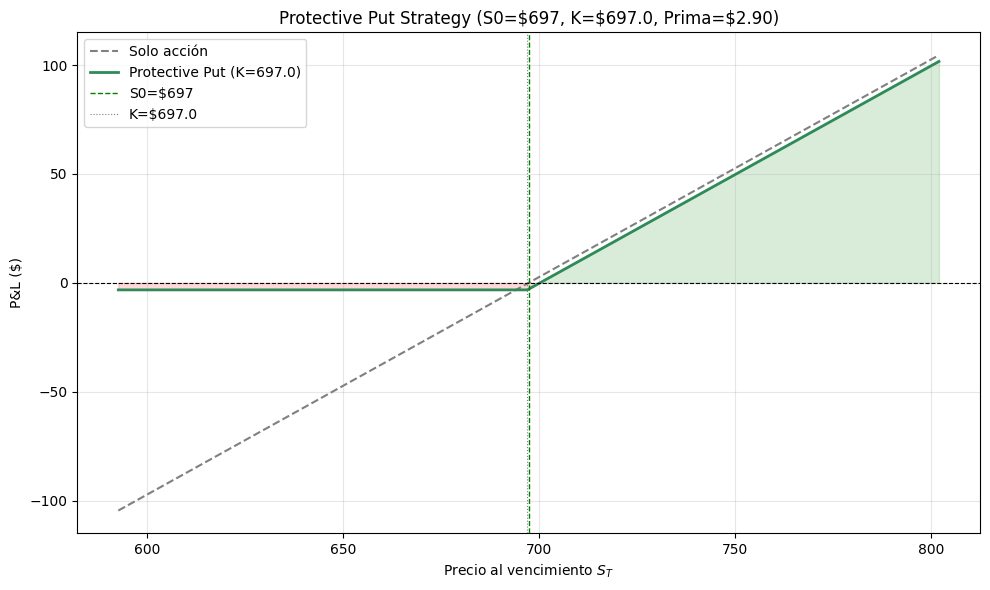

In [7]:
# Compra de acciones + compra de put OTM
# Mercado alcista con protección contra caídas
# Es un seguro, paga prima, tiene piso de pérdida

# Seleccionar put OTM (2-3% abajo del spot)
put_otm_pp = puts[puts['strike'] < S0]
if len(put_otm_pp) > 0:
    K_pp = put_otm_pp.iloc[-1]['strike']
    P_pp = put_otm_pp.iloc[-1]['mid']
else:
    K_pp = atm_strike - 15
    P_pp = 10.0

# Calcular P&L: Long stock + Long put
pnl_protective = pnl_accion + (np.maximum(K_pp - S_range, 0) - P_pp)

perdida_max_pp = -(S0 - K_pp + P_pp)
be_pp = S0 + P_pp

print(f"\nStrike put comprado: ${K_pp}")
print(f"Prima pagada: ${P_pp:.2f}")
print(f"\n Métricas Protective Put:")
print(f"   Prima pagada: ${P_pp:.2f}")
print(f"   Pérdida máxima: ${perdida_max_pp:.2f} (si ST ≤ ${K_pp})")
print(f"   Ganancia máxima: Ilimitada al alza")
print(f"   Break-even: ${be_pp:.2f}")

# comparando con solo acciones
plt.figure(figsize=(10, 6))
plt.plot(S_range, pnl_accion, color='gray', linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_protective, color='seagreen', linewidth=2,
         label=f'Protective Put (K={K_pp})')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0, color='green', linewidth=1.0, linestyle='--', label=f'S0=${S0:.0f}')
plt.axvline(K_pp, color='gray', linewidth=0.8, linestyle=':', label=f'K=${K_pp}')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective>0), alpha=0.15, color='green')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective<0), alpha=0.15, color='red')
plt.xlabel('Precio al vencimiento $S_T$')
plt.ylabel('P&L ($)')
plt.title(f'Protective Put Strategy (S0=${S0:.0f}, K=${K_pp}, Prima=${P_pp:.2f})')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## TABLA RESUMEN CON MÉTRICAS DE CADA ESTRATEGIA

In [8]:
print("TABLA RESUMEN - ESTRATEGIAS NEUTRALES")
print(f" SPY Spot (S0): ${S0:.2f}")
print(f" Vencimiento: {expiry_date}")

print(f"{'Estrategia':<18} {'Prima Neta':<22} {'Ganancia Máx':<22} {'Pérdida Máx':<22} {'Break-even(s)':<25}")
print("-"*95)

# Butterfly (si se pudo construir)
if 'prima_neta_bf' in locals():
    print(f"{'Butterfly':<18} {'Pagada: $' + f'{prima_neta_bf:.2f}':<22} "
          f"{'$' + f'{ganancia_max_bf:.2f}':<22} {'$' + f'{perdida_max_bf:.2f}':<22} "
          f"${be_inf_bf:.2f} y ${be_sup_bf:.2f}")

# Iron Condor (si se pudo construir)
if 'prima_cobrada_ic' in locals():
    print(f"{'Iron Condor':<18} {'Cobrada: $' + f'{prima_cobrada_ic:.2f}':<22} "
          f"{'$' + f'{prima_cobrada_ic:.2f}':<22} {'$' + f'{perdida_max_ic:.2f}':<22} "
          f"${be_low_ic:.2f} y ${be_high_ic:.2f}")

# Covered Call
print(f"{'Covered Call':<18} {'Cobrada: $' + f'{C_cc:.2f}':<22} "
      f"{'$' + f'{ganancia_max_cc:.2f}':<22} {'Ilimitada (teórica)':<22} "
      f"${be_cc:.2f}")

# Protective Put
print(f"{'Protective Put':<18} {'Pagada: $' + f'{P_pp:.2f}':<22} "
      f"{'Ilimitada':<22} {'$' + f'{perdida_max_pp:.2f}':<22} "
      f"${be_pp:.2f}")



TABLA RESUMEN - ESTRATEGIAS NEUTRALES
 SPY Spot (S0): $697.34
 Vencimiento: 2026-04-17
Estrategia         Prima Neta             Ganancia Máx           Pérdida Máx            Break-even(s)            
-----------------------------------------------------------------------------------------------
Butterfly          Pagada: $0.14          $0.86                  $-0.14                 $696.14 y $697.86
Iron Condor        Cobrada: $0.34         $0.34                  $0.66                  $690.66 y $703.34
Covered Call       Cobrada: $2.68         $3.34                  Ilimitada (teórica)    $694.66
Protective Put     Pagada: $2.90          Ilimitada              $-3.24                 $700.24


# **PREGUNTAS**

## Pregunta 1: ¿Cuál de las cuatro estrategias está mejor posicionada (más cerca de su zona de máxima ganancia)? ¿Qué visión de mercado tendría que tener un trader para elegirla hoy?

Con un precio de SPY de 693.69, la estrategia mejor posicionada es el Butterfly Spread porque su zona de máxima ganancia está exactamente en 694 y el precio actual se encuentra a solo 0.31 de ese nivel, una diferencia mínima de menos del 0.05%. El Iron Condor también está bien posicionado porque S0 cae dentro de su zona de ganancia entre 688 y 700 pero el Butterfly tiene la ventaja de estar en su punto óptimo. Para que un trader elija el Butterfly hoy, debe de tener una visión de mercado de alta precisión debe estar extremadamente convencido de que SPY cerrará exactamente en 694 al vencimiento del 17 de abril de 2026. Esta visión solo tendría sentido en situaciones especiales como un vencimiento masivo de opciones donde el "max pain" sea evidente o ante un evento que ancle el precio en ese nivel. Es una apuesta de alta precisión con riesgo muy bajo pero que requiere que el mercado se quede prácticamente quieto.


## Pregunta 2: Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cuál es el peor escenario para tu condor y cuándo ocurre? Calcula la pérdida máxima exacta con tus datos.

El Iron Condor no es una estrategia sin riesgo, aunque se cobre una prima de 0.44 al inicio, se asume un riesgo real. El peor escenario para mi Iron Condor ocurre cuando el precio de SPY al vencimiento cae por debajo de 687 o sube por encima de 701. En estos casos, el inversionista pierde dinero porque ambos spreads (el de puts y el de calls) se ejercen completamente. Con los datos obtenidos, la pérdida máxima es la diferencia entre el strike short put (688) y el strike long put (687) es de 1.00 y a eso se le resta la prima cobrada de 0.44, dando una pérdida máxima de 0.56. Esto significa que por cada 0.44 que puedes ganar, arriesgas 0.56. Es importante recordar que la prima que cobras al inicio no es dinero gratis, sino la compensación que recibes por asumir el riesgo de que el mercado se salga del rango definido.


## Pregunta 3: Si la IV de SPY estuviera en 35% (muy alta), ¿preferirías comprar un straddle (clase pasada) o vender un iron condor? Justifica tu respuesta en términos de vega y theta.

Si la volatilidad implícita de SPY estuviera en 35% (nivel históricamente muy alto) es mejor vender un Iron Condor en lugar de comprar un straddle; por la vega y la theta. El Iron Condor tiene vega negativa, es decir gana valor cuando la volatilidad baja. Con una IV tan alta como 35% lo más probable es que la volatilidad regrese a su media histórica (alrededor del 15-20%) y esa caída beneficiaría al Iron Condor. Por el otro lado, el straddle tiene vega positiva y perdería valor si la IV baja por "volatility crush". Además, el Iron Condor tiene theta positiva gana dinero todos los días por el simple paso del tiempo; mientras que el straddle tiene theta negativa y pierde valor cada día que pasa sin un movimiento grande. Vender volatilidad cuando está cara y dejar que el tiempo trabaje a tu favor es una estrategia con alta probabilidad de éxito. La única excepción sería si esperas un evento que aumente aún más la volatilidad, como una crisis pero en condiciones normales, el Iron Condor es la mejor opción.


## Pregunta 4: El covered call limita la ganancia por encima de K. ¿Por qué un inversionista de largo plazo estaría dispuesto a aceptar ese límite voluntariamente? Da al menos dos razones concretas.

Un inversionista de largo plazo acepta voluntariamente limitar su ganancia en un covered call porque genera un ingreso en mercados laterales. Cuando el mercado no se mueve significativamente, el covered call convierte el "tiempo muerto" en ingresos por primas. Con los datos obtenidos, si SPY se queda entre 689.81 y 694 hasta el vencimiento, el covered call genera ganancia mientras que un inversionista que solo tiene las acciones no gana nada. La prima de 3.88 en solo 3 días representa un retorno del 0.56%, que anualizado sería muy atractivo. Además, la reducción del costo base de la posición, donde cada prima cobrada reduce el precio al que compraste las acciones. En nuestro caso, compramos SPY a 693.69 y cobramos una prima de 3.88, esto redujo el costo base efectivo a 689.81 y crea un colchón de 3.88 contra caídas futuras. Si un inversionista hace esto de manera consistente, puede reducir significativamente su costo base a lo largo del tiempo, protegiéndose contra caídas moderadas y mejorando su retorno total.


## Pregunta 5: Compara el protective put con un seguro de auto. ¿Cuáles son las analogías que funcionan bien? ¿Dónde se rompe la analogía? Piensa en términos de costo, duración, deducible y qué pasa cuando "no usas el seguro".

El protective put es muy similar a un seguro de auto porque el costo es la prima que pagas, en nuestro caso 3.31, igual que pagas una prima mensual o anual por tu seguro. La cobertura funciona de manera similar porque si tienes un accidente (el auto choca) el seguro paga; si SPY cae por debajo de 693, el protective put paga. El deducible, en el seguro de auto es lo que pagas antes de que la aseguradora cubra el resto y en el protective put, el deducible es la diferencia entre el precio actual de SPY y el strike, en este caso es solo 0.69. El seguro de auto tiene una vigencia y el protective put vence el 17 de abril de 2026; sin embargo el seguro de auto no participa del upside, osea si no chocas, solo perdiste la prima y no obtienes ningún beneficio adicional. Mientras que el protective put te permite participar totalmente de las ganancias si SPY sube. Si SPY sube a 720, tu ganancia es de 22.99, a pesar de haber pagado el seguro. El protective put se puede vender antes del vencimiento, si SPY sube y ya no necesitas protección, puedes vender la put en el mercado y recuperar parte de la prima, mientras que el seguro de auto no se puede vender a otra persona. Finalmente, otra diferencia es que el valor del protective put se erosiona con el tiempo por theta negativa, mientras que un seguro de auto mantiene su valor nominal durante toda la vigencia.


## Pregunta 6: ¿En qué se diferencia el butterfly del iron condor en términos de cuándo cada uno es más apropiado? ¿Cuál de los dos requiere mayor precisión en tu pronóstico sobre dónde estará SPY al vencimiento? Apóyate en el ancho de la zona de ganancia que observas en tus gráficas.

La principal diferencia entre el Butterfly y el Iron Condor es el ancho de la zona de ganancia, lo que determina cuánta precisión se necesita en el pronóstico. Con mis datos, el Butterfly tiene una zona de ganancia que va desde 693.08 hasta 694.92, un ancho de 1.84. Esto significa que para que el Butterfly sea rentable, SPY tiene que cerrar en un rango extremadamente estrecho de menos del 0.3% alrededor del strike central. El Iron Condor tiene una zona de ganancia que va desde 687.57 hasta 700.43, un ancho de 12.86, siete veces más amplia. Por lo tanto, el Butterfly requiere una precisión mucho mayor en el pronóstico. A partir de esto, el butterfly es más apropiado cuando un trader tiene una convicción extrema y muy específica sobre dónde cerrará SPY, por ejemplo si sabe que hay un "max pain" evidente en 694 o si espera un evento que ancle el precio exactamente en ese nivel. El Iron Condor es más apropiado cuando el trader solo tiene una visión de rango amplio, es decir, cree que SPY no se moverá mucho pero no necesita acertar un precio exacto. El Butterfly es una apuesta de alta precisión y alto riesgo específico, mientras que el Iron Condor es una estrategia de alta probabilidad pero con ganancia máxima limitada a la prima cobrada.


## Pregunta 7: Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, ¿qué le pasa al valor de tu posición? ¿Por qué?

Si compras un butterfly hoy y mañana la volatilidad implícita cae 5 puntos sin que SPY se mueva, el valor de tu posición aumenta. Esto ocurre porque el butterfly tiene vega negativa. La vega mide cuánto cambia el valor de una opción cuando cambia la volatilidad implícita. Una vega positiva significa que la posición gana si la IV sube; una vega negativa significa que la posición gana si la IV baja. En el butterfly, la vega es negativa porque estás vendiendo dos opciones en el strike central (que tienen la vega más alta por ser ATM) y comprando opciones en los strikes laterales (que tienen menor vega). Con nuestros datos, el strike central en 694 tiene la máxima vega, mientras que los strikes 693 y 695 tienen menor vega. Al estar short en las opciones de mayor vega, cualquier caída en la volatilidad hace que esas opciones pierdan más valor de lo que pierden las opciones largas, generando una ganancia neta. Un cálculo aproximado sugiere que una caída de 5 puntos en la IV podría generar una ganancia de alrededor de 1.00 por contrato. Esta propiedad hace que el butterfly sea una estrategia ideal para momentos posteriores a eventos de incertidumbre, como después de un anuncio de la Reserva Federal o de un reporte de ganancias. Justo después de que se resuelve la incertidumbre, la volatilidad tiende a caer (volatility crush) y el butterfly se beneficia de esa caída incluso si el precio de SPY no se mueve.